In [1]:
import numpy as np
import pydtmc
import pickle
import multiprocessing as mp
from functools import partial
import os
from utils import reorder_transition_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
from pickle import FALSE


def interaction_verticality_1(tm):
    """
    Calculate vertical transport score using monte carlo simulation, and the fraction of vertical steps.
    Args:
        tm np.array: transition matrix, where the first state is the nucleus and the last state is cytoplasm.
        states (i+1) through (i+9) are on the same height for every i%8 = 0.
    Returns: Vertical transport score. (1 = fully vertical, 0 = fully horizontal)
    """
    mc = pydtmc.MarkovChain(tm)
    N_SIMS = 50
    N_STEPS = 1000

    vertical_steps = 0
    horizontal_steps = 0
    for _ in range(N_SIMS):
        sim = mc.simulate(steps = N_STEPS,
                    initial_state = 0, # # initial_state = len(tm)-1,
                    output_indices=True)
        sim = np.array(sim)
        for i in range(N_STEPS - 1):
            state_1 = sim[i]
            state_2 = sim[i+1]
            if (state_1 != 0) and (state_1 != len(tm)-1) and (state_2 != 0) and (state_2 != len(tm)-1):
                spoke = state_1 % 8
                if (state_2 % 8 == spoke):
                    vertical_steps += 1
                else:
                    horizontal_steps += 1
    return vertical_steps / (vertical_steps + horizontal_steps)

def spatial_verticality_2(tm, n=1):
    """
    Calculate vertical transport score using monte carlo simulation, and the fraction of the n most prominent spokes.
    Args:
        tm np.array: transition matrix, where the first state is the nucleus and the last state is cytoplasm.
        states (i+1) through (i+9) are on the same height for every i%8 = 0.
    Returns: Vertical transport score. (1 = fully vertical, 0 = fully horizontal)
    """
    mc = pydtmc.MarkovChain(tm)
    N_SIMS = 100
    N_STEPS = 1000


    most_prominent_spoke_fractions = []
    for _ in range(N_SIMS):
        sim = mc.simulate(steps = N_STEPS,
                    # initial_state = 10, # ~ center of pore
                    output_indices=True)
        # Slice until first occurence:
        sim = np.array(sim)
        indices = np.where((sim == 0) | (sim == len(tm) - 1))[0]
        if len(indices) != 0:
            # raise Exception("Didn't reach nucleus or cytoplasm")
            first_idx = indices[0]
            sim = sim[:first_idx]
        sim = sim - 1 # Remove nucleus state
        sim = sim % 8
        spoke_counts = np.bincount(sim)
        
        # Sort spoke counts in descending order and take the n largest counts
        sorted_counts = np.sort(spoke_counts)[::-1]
        sum_n_most_prominent = np.sum(sorted_counts[:n])
        total_counts = np.sum(spoke_counts)
        most_prominent_spoke_fractions.append(sum_n_most_prominent / total_counts)
    return np.mean(most_prominent_spoke_fractions)

def interaction_verticality_2(tm, n=1, bottom_state=40, top_state=200):
    """
    Calculate vertical transport score using monte carlo simulation, and the fraction of the n most prominent spokes.
    Args:
        tm np.array: transition matrix, where the first state is the nucleus and the last state is cytoplasm.
        states (i+1) through (i+9) are on the same height for every i%8 = 0.
    Returns: Vertical transport score. (1 = fully vertical, 0 = fully horizontal)
    """
    mc = pydtmc.MarkovChain(tm)
    N_SIMS = 100
    # N_STEPS = 10000


    most_prominent_spoke_fractions = []
    for _ in range(N_SIMS):
        cur_state = np.random.randint(bottom_state, top_state)
        sim = [cur_state]
        while cur_state > bottom_state and cur_state < top_state:
            cur_state = np.random.choice(range(len(tm)), p=tm[cur_state])
            sim.append(cur_state)
        sim = np.array(sim)
        
        sim = sim - 1 # Remove nucleus state
        sim = sim % 8
        spoke_counts = np.bincount(sim)
        
        # Sort spoke counts in descending order and take the n largest counts
        sorted_counts = np.sort(spoke_counts)[::-1]
        sum_n_most_prominent = np.sum(sorted_counts[:n])
        total_counts = np.sum(spoke_counts)
        most_prominent_spoke_fractions.append(sum_n_most_prominent / total_counts)
    return np.mean(most_prominent_spoke_fractions)

def interaction_verticality_3(tm, n=1, bottom_layer=0, top_layer=28):
    """
    Calculate vertical transport score using monte carlo simulation, and the fraction of the n most prominent spokes.
    There are 27 layers 
    so 0 = nucleus
    1-27 = fg nups
    28 = cytoplasm 
    Args:
        tm np.array: transition matrix, where the first state is the nucleus and the last state is cytoplasm.
        states (i+1) through (i+9) are on the same height for every i%8 = 0.
    Returns: Vertical transport score. (1 = fully vertical, 0 = fully horizontal)
    """
    mc = pydtmc.MarkovChain(tm)
    N_SIMS = 1000
    # N_STEPS = 10000

    # if bottom_layer >= top_layer: 
    #     print(bottom_layer, top_layer)
    #     raise ValueError("Bottom layer must be smaller than top layer")
    if bottom_layer == top_layer: return 0
    
    def state_to_layer(state):
        if state == 0: return 0
        elif state == 217: return 28
        else: return ((state - 1) // 8) + 1
    
    top_to_bottom = False
    if bottom_layer > top_layer:
        top_to_bottom = True
        bottom_layer, top_layer = top_layer, bottom_layer
        
    if top_to_bottom:
        if top_layer == 0: init_state = 0
        elif top_layer == 28: init_state = 217
        else: init_state = top_layer * 8
    else:
        if bottom_layer == 0: init_state = 0
        elif bottom_layer == 28: init_state = 217
        else: init_state = bottom_layer * 8

    most_prominent_spoke_fractions = []
    for _ in range(N_SIMS):
        cur_state = init_state
        sim = [cur_state]
        while True:
            cur_state = np.random.choice(range(len(tm)), p=tm[cur_state])
            sim.append(cur_state)
            layer = state_to_layer(cur_state)
            if top_to_bottom and (layer <= bottom_layer or layer > top_layer):
                break
            if not top_to_bottom and (layer < bottom_layer or layer >= top_layer):
                break
        if top_to_bottom and (layer > top_layer):
            continue
        if not top_to_bottom and (layer < bottom_layer):
            continue

        sim = np.array(sim)        
        sim = sim - 1 
        sim = sim[sim != -1] # Remove nucleus state
        sim = sim % 8
        spoke_counts = np.bincount(sim)
        
        # Sort spoke counts in descending order and take the n largest counts
        sorted_counts = np.sort(spoke_counts)[::-1]
        sum_n_most_prominent = np.sum(sorted_counts[:n])
        total_counts = np.sum(spoke_counts)
        most_prominent_spoke_fractions.append(sum_n_most_prominent / total_counts)
    return np.mean(most_prominent_spoke_fractions)

def interaction_verticality_from_path(matrix_path, variant=1, n=1, bottom_state=40, top_state=200):
    with open(matrix_path, "rb") as f:
        tm, states = pickle.load(f)
        
    # Load anchor coordinates
    with open(f"data/anchor_coordinates.pickle", "rb") as f:
        anchor_coordinates = pickle.load(f)
    
    # Sort anchor coordinates by Z and reorder transition matrix
    anchor_coordinates = dict(sorted(anchor_coordinates.items(), key=lambda x: x[1][2]))
    new_states = ["nuc"] + list(anchor_coordinates.keys()) + ["cyt"]
    tm = reorder_transition_matrix(tm, states, new_states)  
    
    if variant == 1:
        return interaction_verticality_1(tm)
    elif variant == 2:
        return interaction_verticality_2(tm, n=n, top_state=top_state, bottom_state=bottom_state)
    elif variant == 3:
        return interaction_verticality_3(tm, n=n, top_layer=top_state, bottom_layer=bottom_state) 
    else:
        raise ValueError(f"Variant {variant} not implemented")
    
def spatial_verticality_from_path(matrix_path, variant=1, n=1):
    with open(matrix_path, "rb") as f:
        tm = pickle.load(f)
    
    if variant == 1:
        return interaction_verticality_1(tm)
    if variant == 2:
        return spatial_verticality_2(tm, n)
    else:
        raise ValueError(f"Variant {variant} not implemented")

In [ ]:
# VARIANTS FOR GROUPED ANALYSIS

def grouped_interaction_verticality(tm, n=1, bottom_layer=0, top_layer=200):
    """
    Calculate vertical transport score using monte carlo simulation, and the fraction of the n most prominent spokes.
    There are 5 layers 
    so 0 = nucleus
    1-3 = fg nups
    4 = cytoplasm 
    Args:
        tm np.array: transition matrix, where the first state is the nucleus and the last state is cytoplasm.
        states (i+1) through (i+9) are on the same height for every i%8 = 0.
    Returns: Vertical transport score. (1 = fully vertical, 0 = fully horizontal)
    """
    mc = pydtmc.MarkovChain(tm)
    N_SIMS = 100
    # N_STEPS = 10000

    if bottom_layer >= top_layer: 
        print(bottom_layer, top_layer)
        raise ValueError("Bottom layer must be smaller than top layer")

    if bottom_layer == 0: init_state = 0
    else: init_state = bottom_layer * 8 # TODO make other like this?

    most_prominent_spoke_fractions = []
    for _ in range(N_SIMS):
        cur_state = init_state
        sim = [cur_state]
        while True:
            cur_state = np.random.choice(range(len(tm)), p=tm[cur_state])
            sim.append(cur_state)
            if (cur_state // 8) < bottom_layer or (cur_state // 8) + 1 >= top_layer:
                break
        if cur_state // 8 < bottom_layer:
            continue

        sim = np.array(sim)        
        sim = sim - 1 
        sim = sim[sim != -1] # Remove nucleus state
        sim = sim % 8
        spoke_counts = np.bincount(sim)
        
        # Sort spoke counts in descending order and take the n largest counts
        sorted_counts = np.sort(spoke_counts)[::-1]
        sum_n_most_prominent = np.sum(sorted_counts[:n])
        total_counts = np.sum(spoke_counts)
        most_prominent_spoke_fractions.append(sum_n_most_prominent / total_counts)
    return np.mean(most_prominent_spoke_fractions)

def grouped_interaction_verticality_from_path(matrix_path, variant=1, n=1, bottom_state=40, top_state=200):
    with open(matrix_path, "rb") as f:
        tm, states = pickle.load(f)
    
    return grouped_interaction_verticality(tm, n=n, top_layer=top_state, bottom_layer=bottom_state) 

In [ ]:
interaction_verticality_from_path(f"data/transition_matrices/interactions-150-180-symmetric-{100}ns.pickle", variant=1)

0.509165538435089

In [5]:
for n in [1,2,3]:
    verticality = interaction_verticality_from_path(f"data/transition_matrices/interactions-150-180-symmetric-{100}ns.pickle", variant=2, n=n)
    print(f"{n} verticality for interactions: {verticality}")

1 verticality for interactions: 0.7320505721668513
2 verticality for interactions: 0.9297177369653642
3 verticality for interactions: 0.9811313131313131


In [40]:
def calculate_verticality_single(args):
    bottom_state, top_state, n, path = args
    verticality = interaction_verticality_from_path(
        path, 
        variant=3, 
        n=n, 
        bottom_state=bottom_state, 
        top_state=top_state
    )
    return bottom_state, top_state, verticality

# Main calculation
def calculate_verticalities(n, path=None):
    if path is None:
        path = f"data/transition_matrices/interactions-150-180-symmetric-{100}ns.pickle"
    
    state_range = range(0, 29)
    verticalities = np.zeros((29, 29))
    args_list = [(bottom_state, top_state, n, path) for top_state in state_range for bottom_state in state_range]
    num_cpus = len(os.sched_getaffinity(0))
    print(f"Using {num_cpus} CPUs")
    with mp.Pool(processes=num_cpus) as pool:
        results = pool.map(calculate_verticality_single, args_list)
    for bottom_state, top_state, verticality in results:
        verticalities[bottom_state, top_state] = verticality
    return verticalities



In [19]:
def visualize_verticalities(verticalities, layer_names = None, title="Verticality"):
    if layer_names is None:
        layer_names = ["Nuc", "Nup2", "Nup60", "Nup2", "Nup60", "Nup1", "Nup145", 
                "Nup49", "Nsp1", "Nup49", "Nsp1", "Nup57", "Nup145", 
                "Nup57", "Nup57", "Nup57", "Nsp1", "Nup49", "Nsp1", 
                "Nup49", "Nup100", "Nup159", "Nup100", "Nup159", 
                "Nsp1", "Nsp1", "Nup116", "Nup116", "Cyt"]
    # Get dimensions
    n = verticalities.shape[0]
    
    # Create a mask for the lower triangle (including diagonal)
    # mask = np.tril(np.ones_like(verticalities))
    mask = np.eye(verticalities.shape[0])
    
    # Create a figure
    fig, ax = plt.subplots(figsize=(14, 12))
    
    # Plot using Seaborn for better triangle heatmap support
    sns.heatmap(verticalities,
                mask=mask, 
                cmap="turbo", 
                square=True, linewidths=.5, cbar_kws={"shrink": .5},
                annot=True, fmt=".2f", annot_kws={"size": 7}, vmin=0, vmax=1)
    
    # Define layer names

    
    # Set tick labels
    ax.set_xticklabels(layer_names, rotation=90)
    ax.set_yticklabels(layer_names, rotation=0)
    
    # Move x-axis labels to the top
    ax.xaxis.tick_top()
    
    plt.xlabel("Top layer")
    plt.ylabel("Bottom layer")
    plt.title(title)
    
    plt.tight_layout()
    plt.show()

In [60]:
verticalities = calculate_verticalities(1)
with open("data/verticality_matrices/interactions-150-180-symmetric-100ns-1spoke-ver3.pickle", "wb") as f:
    pickle.dump(verticalities, f)

Using 16 CPUs


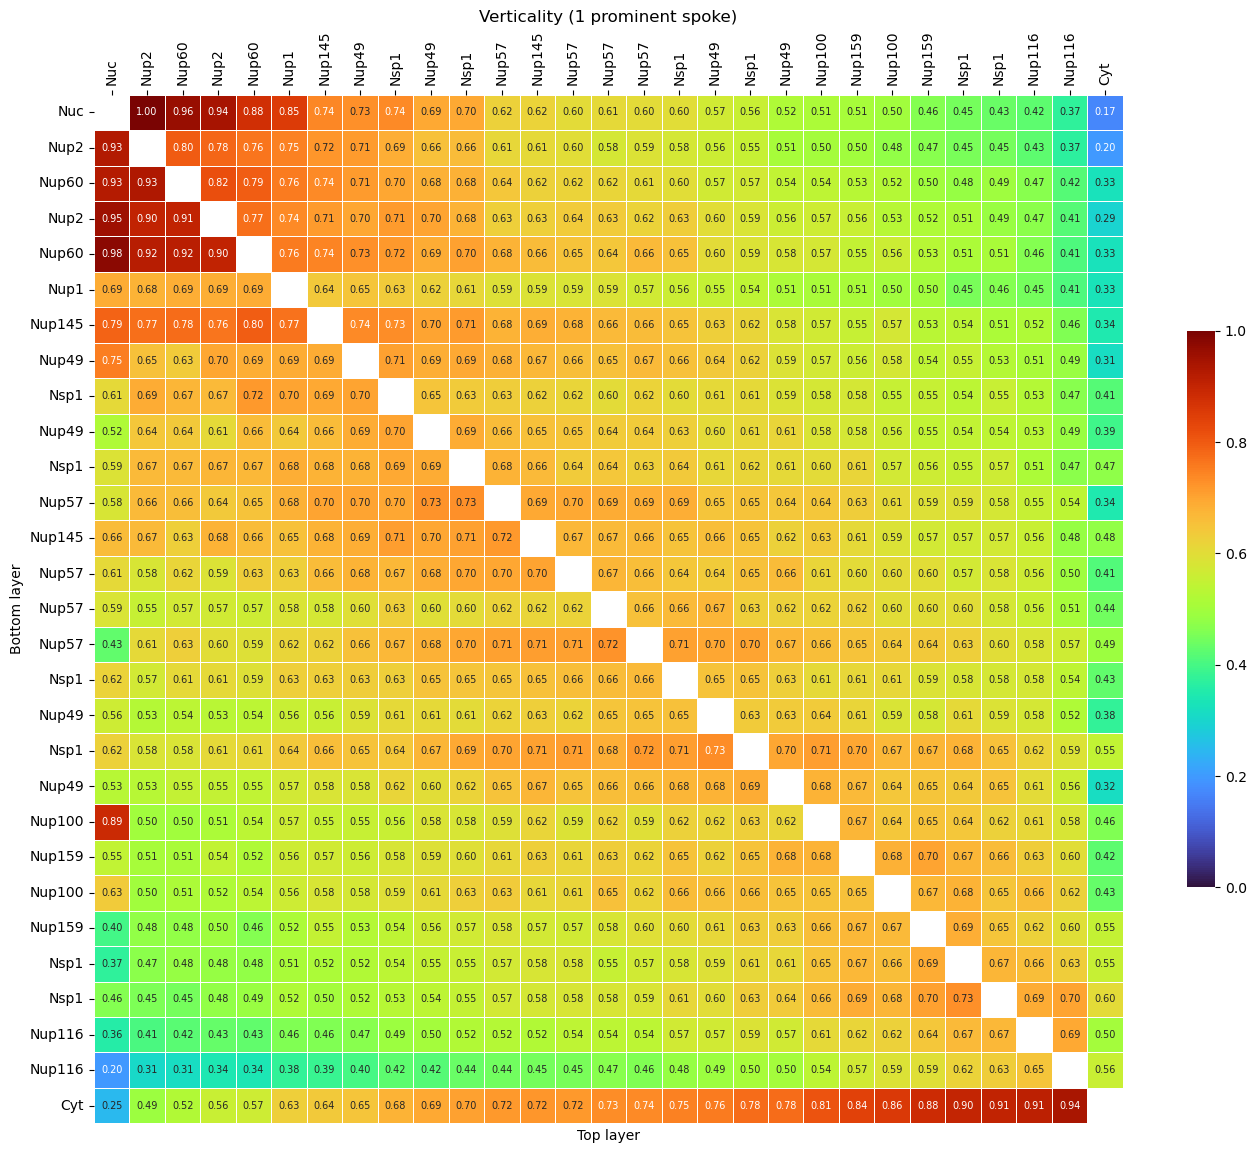

In [53]:
with open("data/verticality_matrices/interactions-150-180-symmetric-100ns-1spoke-ver3.pickle", "rb") as f:
    verticalities = pickle.load(f)
visualize_verticalities(verticalities, title="Verticality (1 prominent spoke)")

In [61]:
verticalities = calculate_verticalities(2)
with open("data/verticality_matrices/interactions-150-180-symmetric-100ns-2spoke-ver3.pickle", "wb") as f:
    pickle.dump(verticalities, f)

Using 16 CPUs


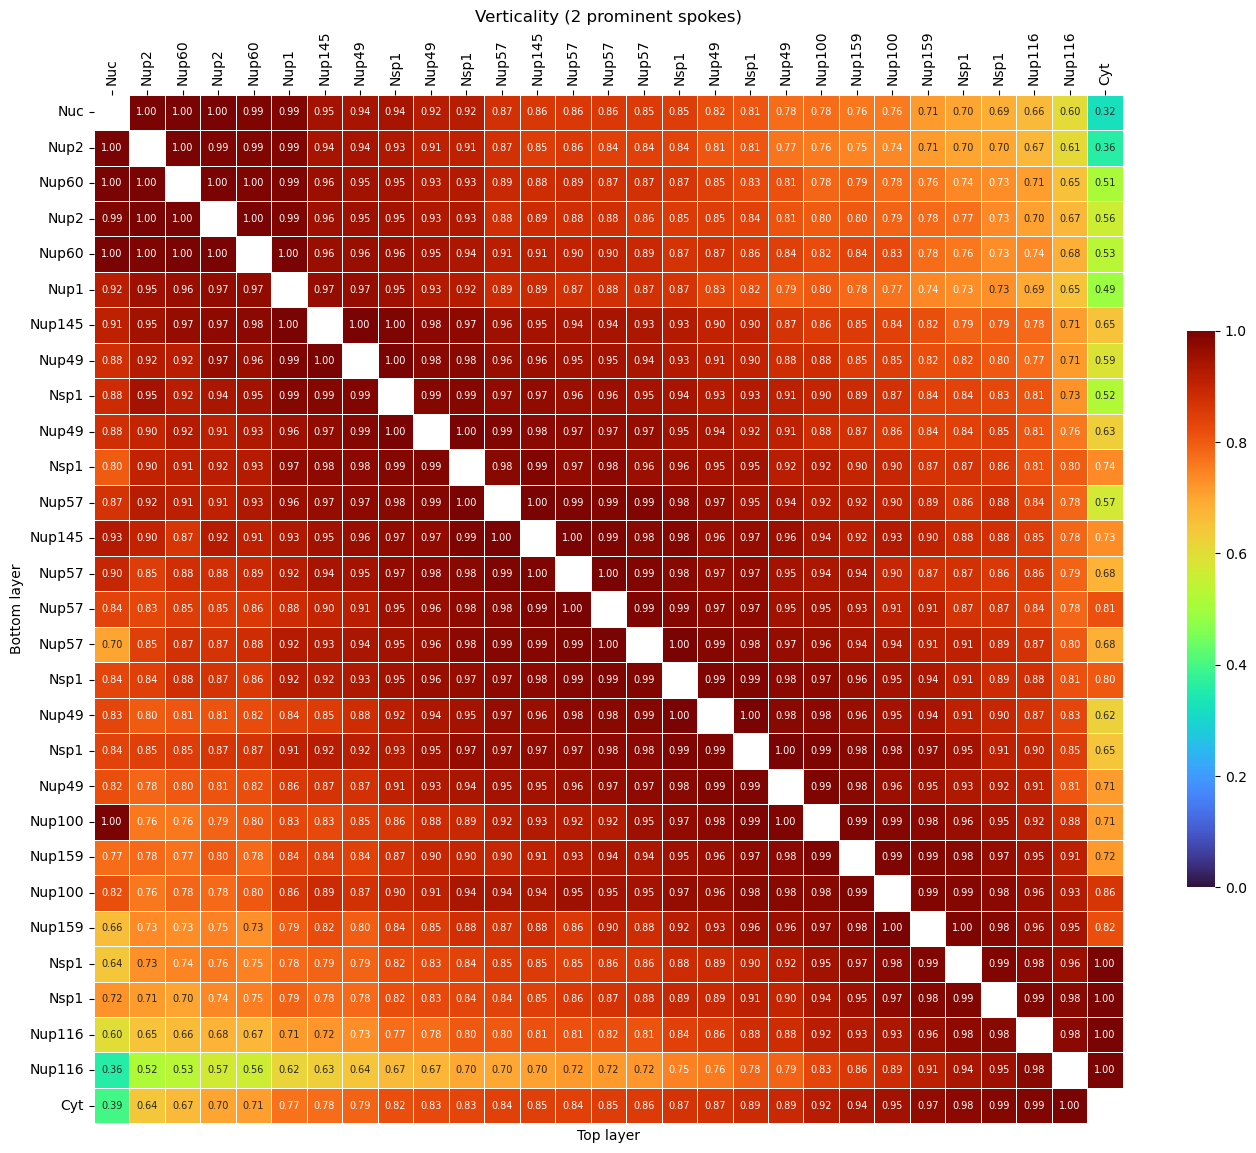

In [62]:
with open("data/verticality_matrices/interactions-150-180-symmetric-100ns-2spoke-ver3.pickle", "rb") as f:
    verticalities = pickle.load(f)
visualize_verticalities(verticalities, title="Verticality (2 prominent spokes)")

In [98]:
verticalities = verticalities = np.zeros((5, 5))
for i in range(5):
    for j in range(i):
        verticalities[j, i] = grouped_interaction_verticality_from_path(
                                        matrix_path="/cs/usr/roi.eliasian/LabFolder/Master/NPC-markov/data/transition_matrices/interactions-150-180-symmetric-grouped-100ns.pickle",
                                        variant=1,
                                        n=1,
                                        bottom_state=j,
                                        top_state=i)
with open("data/verticality_matrices/interactions-150-180-symmetric-100ns-grouped-1spoke-ver3.pickle", "wb") as f:
    pickle.dump(verticalities, f)

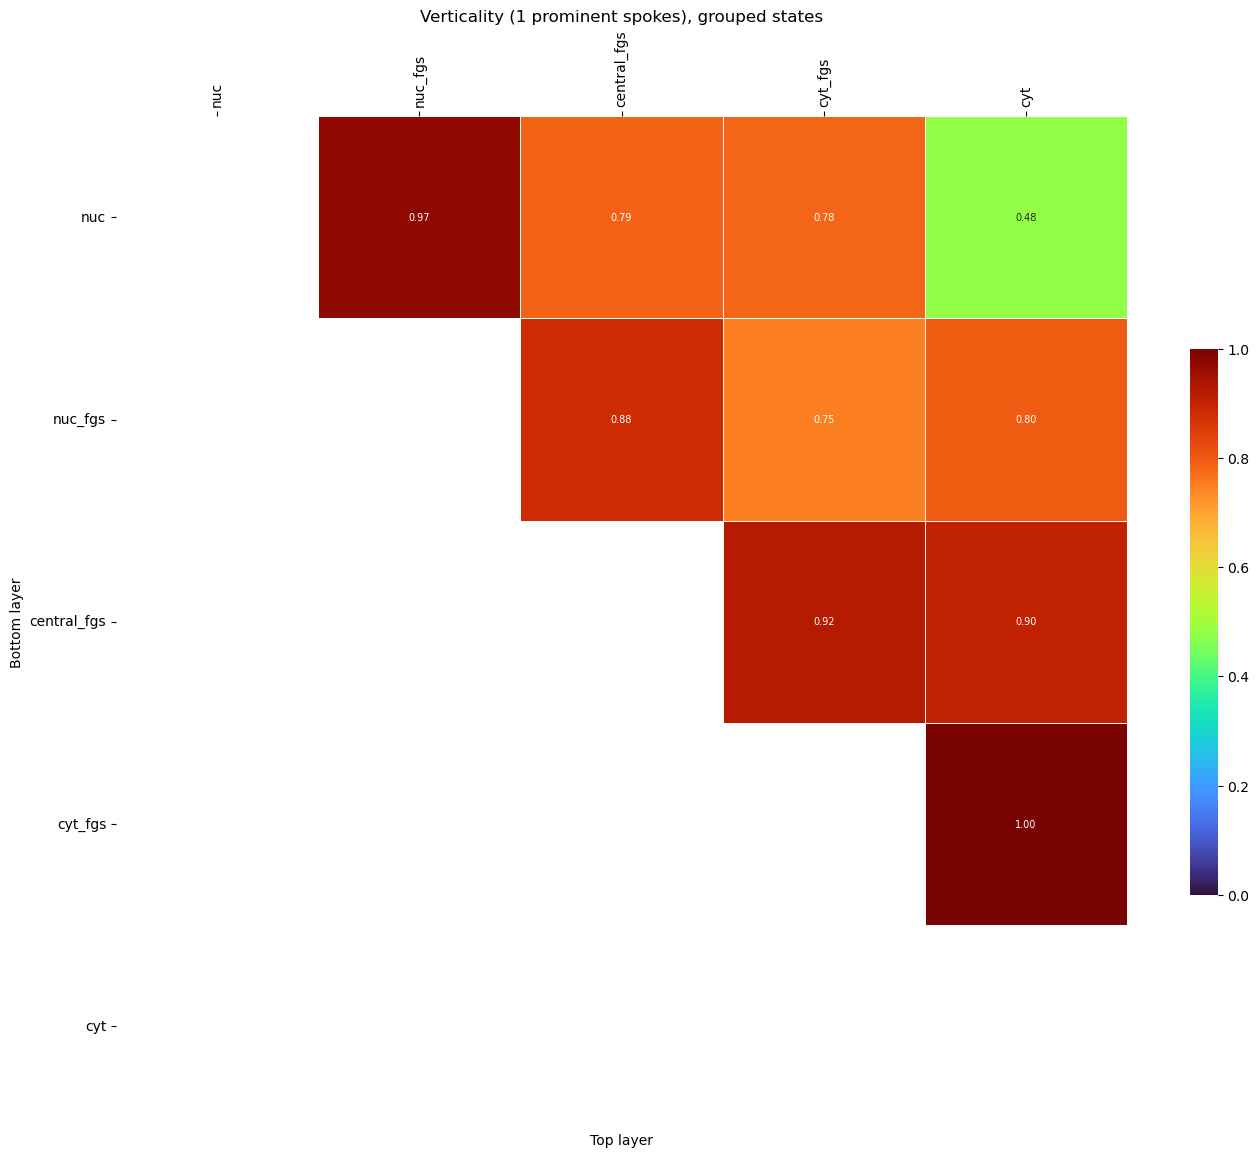

In [116]:
with open("data/verticality_matrices/interactions-150-180-symmetric-100ns-grouped-1spoke-ver3.pickle", "rb") as f:
    verticalities = pickle.load(f)
visualize_verticalities(verticalities, layer_names=["nuc", "nuc_fgs", "central_fgs", "cyt_fgs", "cyt"], title="Verticality (1 prominent spokes), grouped states")